In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neurocipher/heartdisease")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dmadd\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1


In [7]:
import os

os.listdir(path)


['Heart_Disease_Prediction.csv']

In [39]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


In [9]:
import os
import pandas as pd

# Automatically find the CSV in the KaggleHub directory
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No CSV file found in KaggleHub dataset directory.")

DATA_PATH = os.path.join(path, csv_files[0])
print("Using:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()


Using: C:\Users\dmadd\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1\Heart_Disease_Prediction.csv


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
#Sex: 1 = male, 0= female
#Binary classification (heart disease: 0 = No, 1 = Yes)

In [10]:
df.shape

(270, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [34]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR',
       'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [13]:
df.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [14]:
display(df.info())
display(df.describe(include="all").T)

# Missing + duplicates
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("Duplicates:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,270.0,NaN,NaN,NaN,54.433333,9.109067,29.0,48.0,55.0,61.0,77.0
Sex,270.0,NaN,NaN,NaN,0.677778,0.468195,0.0,0.0,1.0,1.0,1.0
Chest pain type,270.0,NaN,NaN,NaN,3.174074,0.95009,1.0,3.0,3.0,4.0,4.0
BP,270.0,NaN,NaN,NaN,131.344444,17.861608,94.0,120.0,130.0,140.0,200.0
Cholesterol,270.0,NaN,NaN,NaN,249.659259,51.686237,126.0,213.0,245.0,280.0,564.0
FBS over 120,270.0,NaN,NaN,NaN,0.148148,0.355906,0.0,0.0,0.0,0.0,1.0
EKG results,270.0,NaN,NaN,NaN,1.022222,0.997891,0.0,0.0,2.0,2.0,2.0
Max HR,270.0,NaN,NaN,NaN,149.677778,23.165717,71.0,133.0,153.5,166.0,202.0
Exercise angina,270.0,NaN,NaN,NaN,0.32963,0.470952,0.0,0.0,0.0,1.0,1.0
ST depression,270.0,NaN,NaN,NaN,1.05,1.14521,0.0,0.0,0.8,1.6,6.2


Series([], dtype: int64)

Duplicates: 0


In [23]:
print("Raw target values:")
print(df[TARGET_COL].value_counts(dropna=False))


Raw target values:
Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


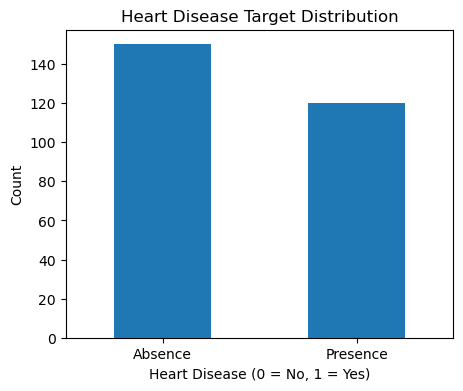

In [35]:
TARGET_COL = "Heart Disease"  # change if needed

plt.figure(figsize=(5,4))
df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#shows class balance

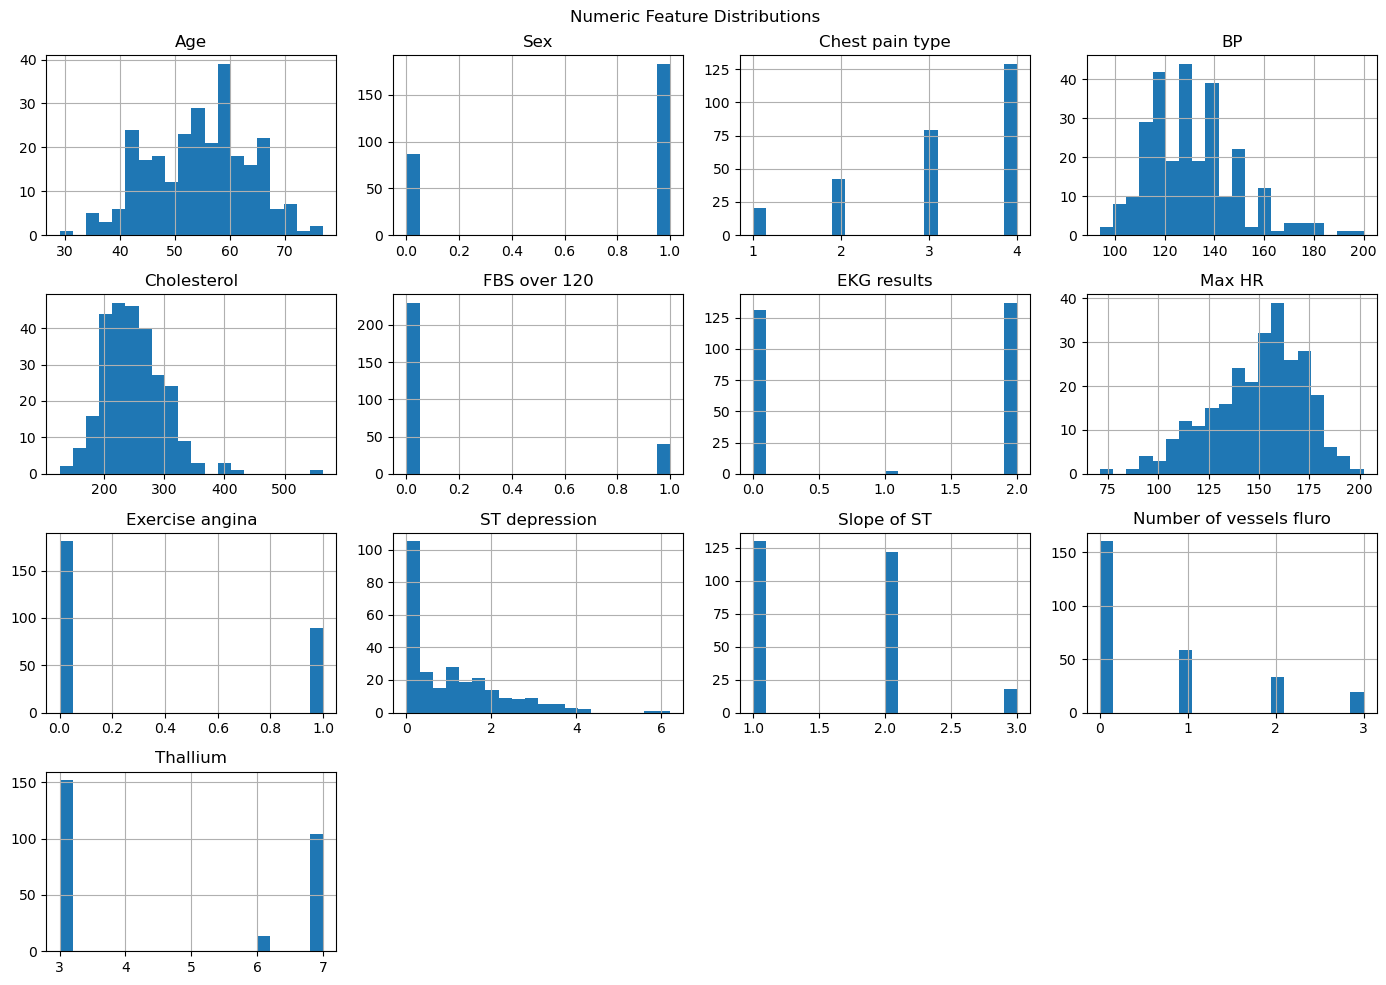

In [37]:
# First, check if TARGET_COL exists and is numeric
num_cols = df.select_dtypes(include="number").columns.tolist()

# Only try to remove TARGET_COL if it's in the list
if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

# Create histograms
df[num_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

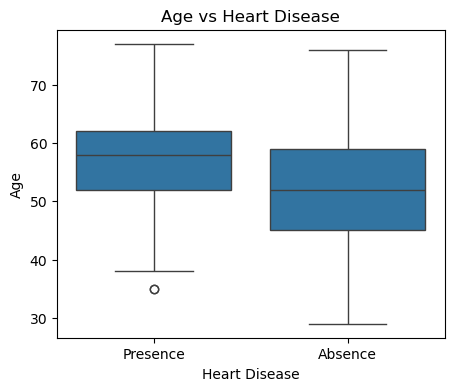

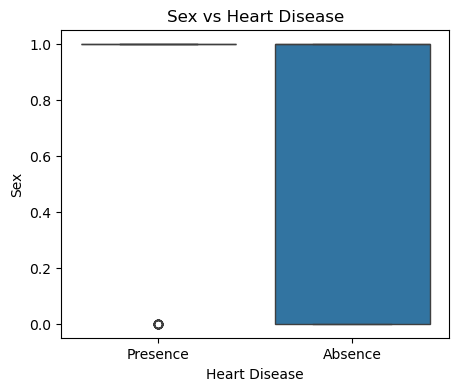

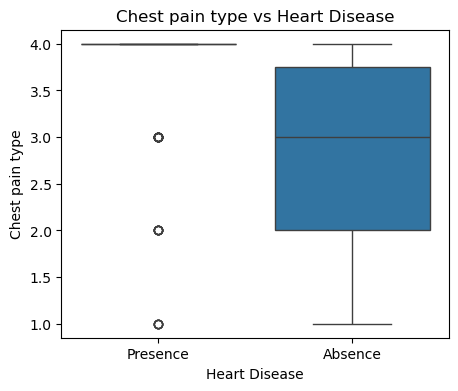

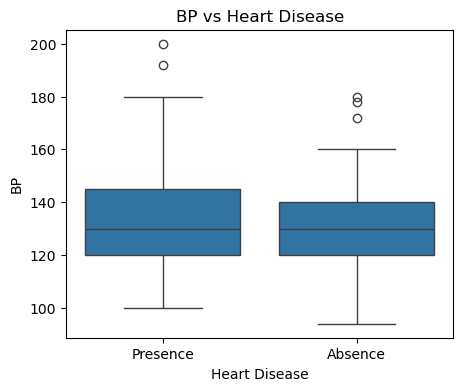

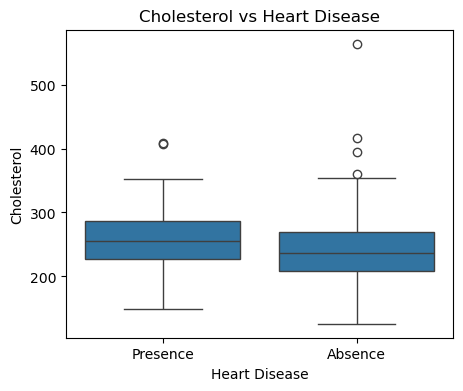

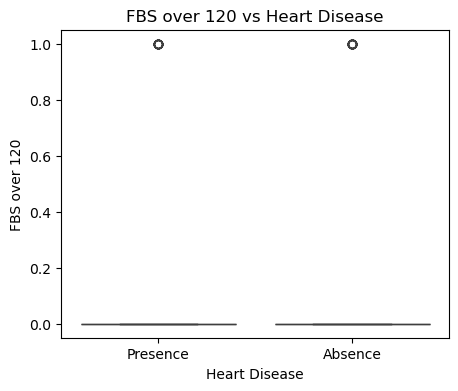

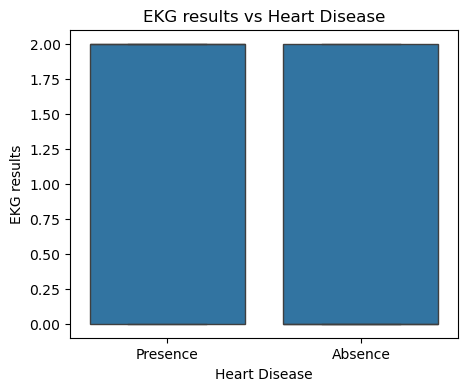

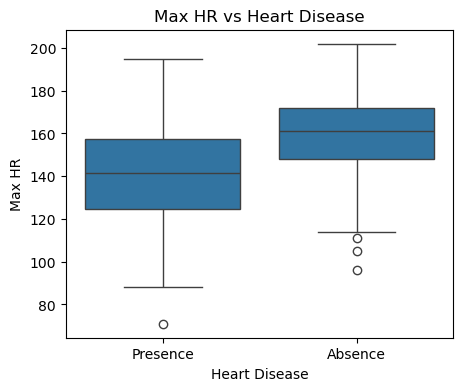

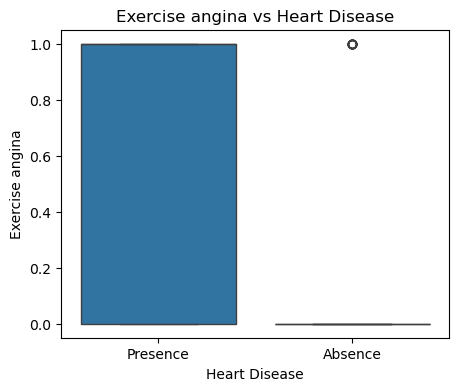

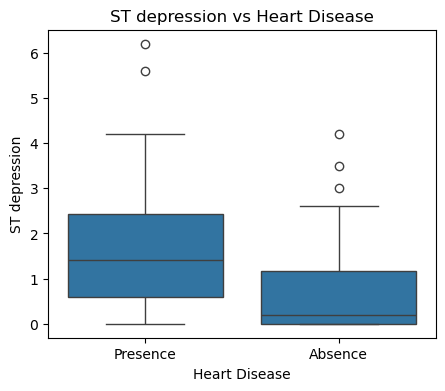

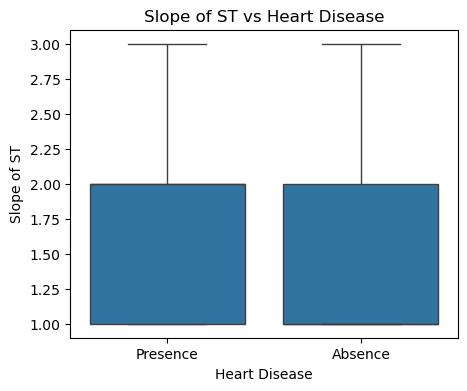

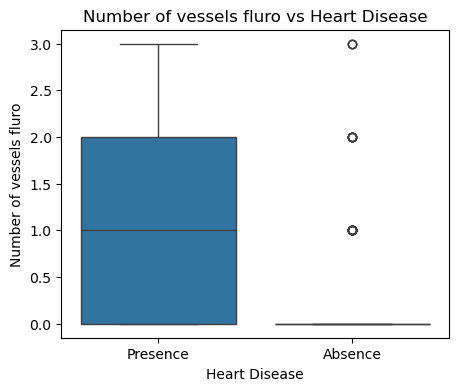

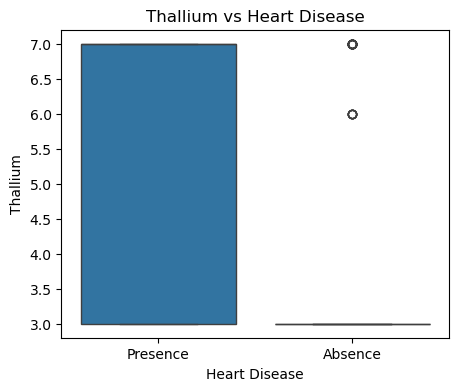

In [40]:
for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[TARGET_COL], y=df[col])
    plt.title(f"{col} vs Heart Disease")
    plt.xlabel("Heart Disease")
    plt.ylabel(col)
    plt.show()


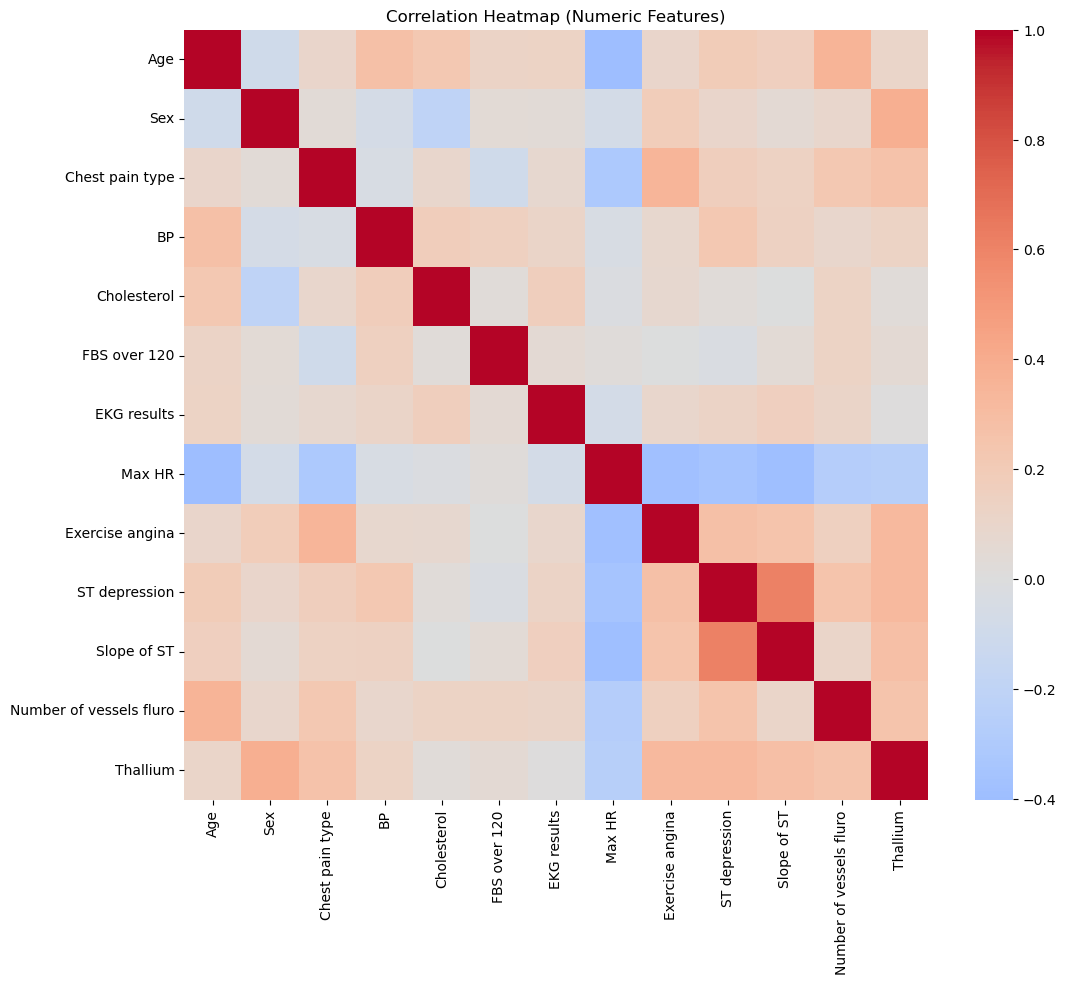

In [44]:
# First, check if TARGET_COL contains string values
# If TARGET_COL is categorical, we need to exclude it from correlation calculation
plt.figure(figsize=(12,10))

# Only include numeric columns for correlation
num_cols_only = [col for col in num_cols if df[col].dtype in ['int64', 'float64']]

# Calculate correlation only for numeric columns
corr = df[num_cols_only].corr()

# Create heatmap
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

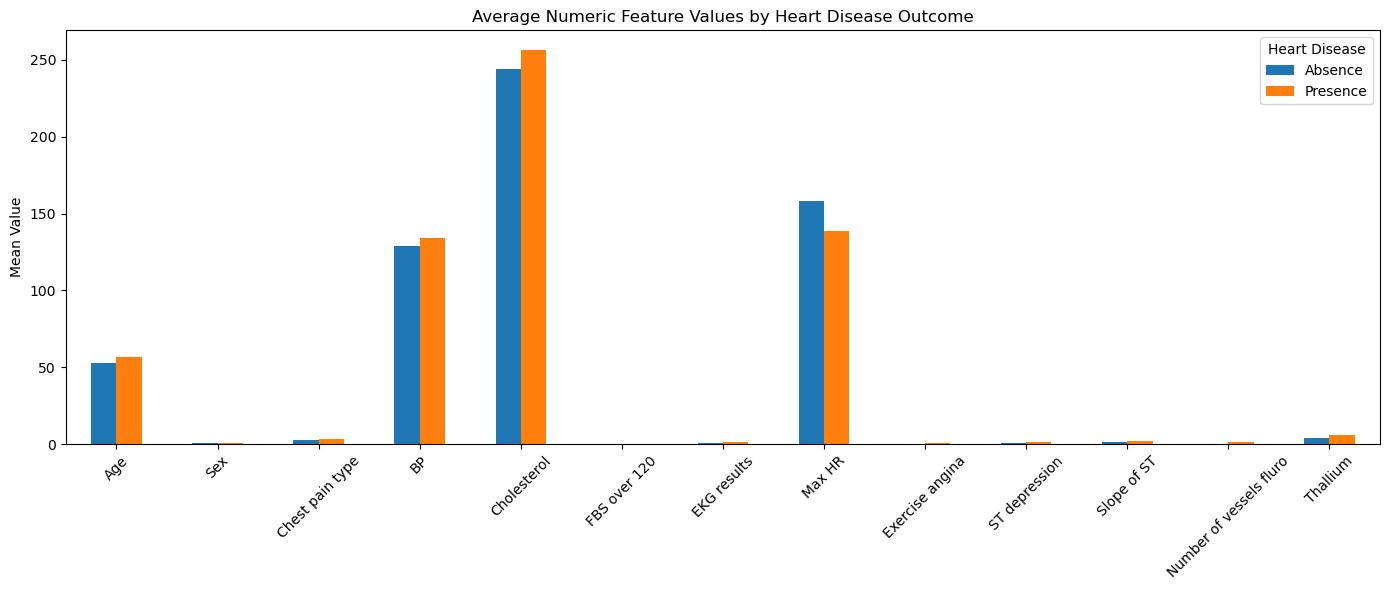

In [45]:
group_means = df.groupby(TARGET_COL)[num_cols].mean().T

group_means.plot(kind="bar", figsize=(14,6))
plt.title("Average Numeric Feature Values by Heart Disease Outcome")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
### 🔑 Key EDA Insights
- The dataset shows a (balanced / imbalanced) target distribution.
- Several numeric features show clear separation between heart disease classes.
- Certain categorical variables demonstrate higher disease prevalence.
- Some features exhibit strong correlations, indicating potential redundancy.


In [46]:
#Preprocessing and Train/Test Split

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

TARGET_COL = "Heart Disease"  # change if needed

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

# If target is text like Presence/Absence, map it here:
if y.dtype == "object":
    y_raw = y.astype(str).str.strip().str.lower()
    mapping = {
        "1": 1, "yes": 1, "true": 1, "presence": 1, "disease": 1,
        "0": 0, "no": 0, "false": 0, "absence": 0, "no disease": 0
    }
    y = y_raw.map(mapping)
    if y.isna().any():
        print("Unmapped labels:\n", y_raw[y.isna()].value_counts())
        raise ValueError("Unmapped target labels detected. Update mapping above.")

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Target balance (train):")
print(y_train.value_counts(normalize=True))


Train: (216, 13) Test: (54, 13)
Target balance (train):
Heart Disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64


,model,acc_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
1,SVC_RBF,0.833087,0.828085,0.802105,0.808800,0.903662
0,LogReg,0.819239,0.813546,0.781579,0.793124,0.897610
3,RF,0.823784,0.837649,0.760000,0.791609,0.895230
2,KNN,0.819556,0.819531,0.771579,0.789326,0.891086
5,HGB,0.796089,0.787203,0.760526,0.770229,0.883947
4,GB,0.791543,0.744524,0.812632,0.775832,0.881601


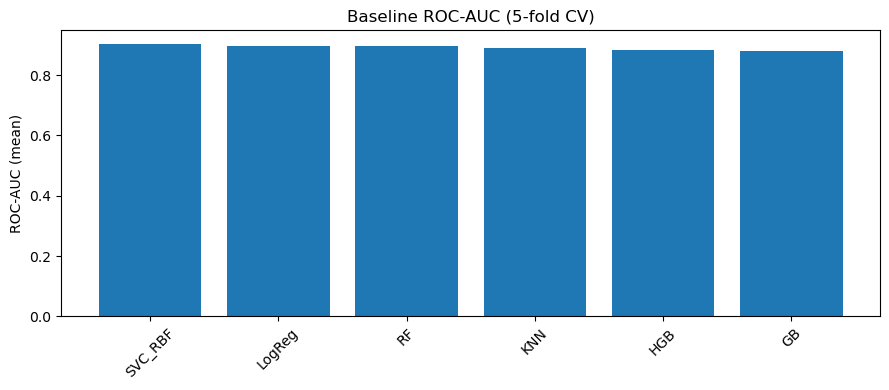

In [47]:
#Baseline Models and Cross-Validation Metrics

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "SVC_RBF": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "HGB": HistGradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                         ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
    })

results = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
display(results)

plt.figure(figsize=(9,4))
plt.bar(results["model"], results["roc_auc_mean"])
plt.title("Baseline ROC-AUC (5-fold CV)")
plt.ylabel("ROC-AUC (mean)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [48]:
#Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_distributions = {
    "model__n_estimators": randint(200, 1200),
    "model__max_depth": randint(2, 25),
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 15),
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best ROC-AUC (CV):", rf_search.best_score_)
print("Best Params:")
display(rf_search.best_params_)

best_model = rf_search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best ROC-AUC (CV): 0.9055921052631579
Best Params:


{'model__class_weight': None,
 'model__max_depth': 12,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 14,
 'model__n_estimators': 359}

Accuracy: 0.8333333333333334
Precision: 0.8
Recall: 0.8333333333333334
F1: 0.8163265306122449
ROC-AUC: 0.888888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



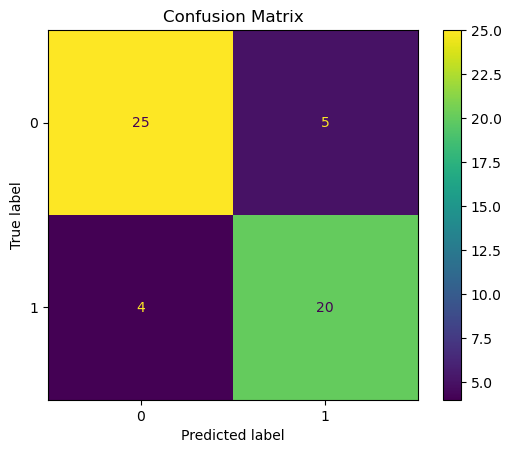

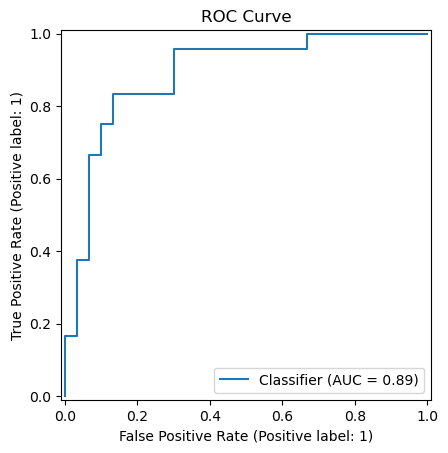

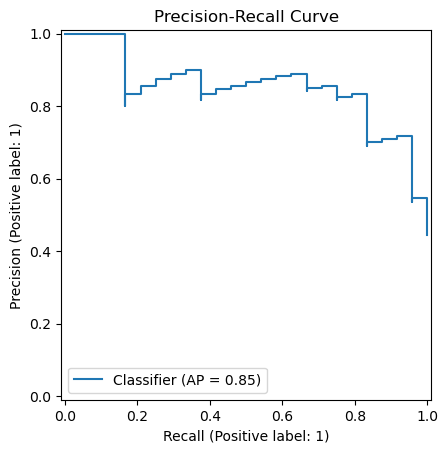

In [49]:
#Final Test Evaluation and Visuals (Confusion, ROC, PR)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
if y_proba is not None:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

# ROC + PR curves
if y_proba is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title("Precision-Recall Curve")
    plt.show()


,feature,importance_mean,importance_std
12,Thallium,4.320988e-02,0.029215
11,Number of vessels fluro,3.333333e-02,0.024568
2,Chest pain type,2.962963e-02,0.026878
9,ST depression,2.098765e-02,0.022291
7,Max HR,1.481481e-02,0.023619
10,Slope of ST,1.358025e-02,0.015810
4,Cholesterol,3.703704e-03,0.010030
8,Exercise angina,3.700743e-17,0.025301
1,Sex,0.000000e+00,0.000000
5,FBS over 120,0.000000e+00,0.000000


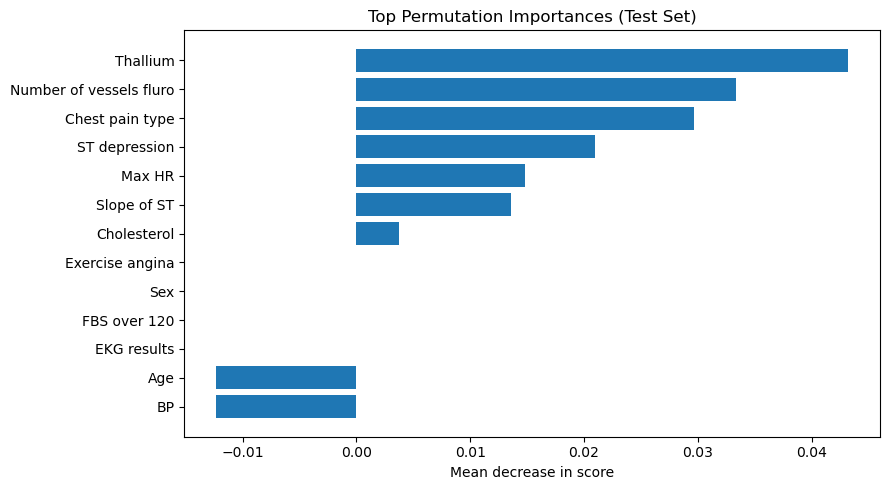

In [51]:
#Feature Importance
from sklearn.inspection import permutation_importance

# Build feature names after preprocessing
feature_names = []
feature_names.extend(num_cols)

cat_pipe = best_model.named_steps["preprocessor"].named_transformers_.get("cat", None)
if cat_pipe is not None:
    # Check if the pipeline has been fitted before accessing the OneHotEncoder
    if hasattr(cat_pipe, "named_steps") and "onehot" in cat_pipe.named_steps:
        ohe = cat_pipe.named_steps["onehot"]
        # Check if the OneHotEncoder has been fitted
        if hasattr(ohe, "get_feature_names_out"):
            try:
                # Try to get the feature names
                feature_names.extend(ohe.get_feature_names_out(cat_cols).tolist())
            except Exception as e:
                print(f"Warning: Could not get feature names: {e}")
                # Fallback: Create generic feature names for categorical variables
                for col in cat_cols:
                    feature_names.append(f"{col}_encoded")

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)

# Make sure the number of features matches the permutation importance results
if len(feature_names) != perm.importances_mean.shape[0]:
    print(f"Warning: Feature names count ({len(feature_names)}) doesn't match importance count ({perm.importances_mean.shape[0]})")
    # Create generic feature names if counts don't match
    feature_names = [f"feature_{i}" for i in range(perm.importances_mean.shape[0])]

imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp.head(20))

top = imp.head(15).iloc[::-1]
plt.figure(figsize=(9,5))
plt.barh(top["feature"], top["importance_mean"])
plt.title("Top Permutation Importances (Test Set)")
plt.xlabel("Mean decrease in score")
plt.tight_layout()
plt.show()

In [ ]:
#From Baseline Models and Cross Validation Metrics
#🏆 Model comparison takeaway (based on your results)

#Your best-performing model is clearly:

#✅ SVC with RBF kernel

#ROC-AUC: 0.9037 ← highest

#Accuracy: 0.833

#F1: 0.809 (best overall balance)

#Strong precision and recall

#This is exactly what we want for a medical classification problem:

#High discrimination (ROC-AUC) + balanced errors

#Why not Random Forest?

#RF has slightly higher precision

#But lower recall + lower ROC-AUC

#In healthcare, missing positives is worse than false alarms

📌 Decision:
#👉 Tune SVC_RBF, not Random Forest

In [52]:
#SVC Hyperparameter Tuning (RandomizedSearchCV)
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

svc_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

param_distributions = {
    "model__C": loguniform(1e-2, 1e2),
    "model__gamma": loguniform(1e-4, 1e-1),
    "model__class_weight": [None, "balanced"]
}

svc_search = RandomizedSearchCV(
    svc_pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

svc_search.fit(X_train, y_train)

print("Best ROC-AUC (CV):", svc_search.best_score_)
print("Best Parameters:")
display(svc_search.best_params_)

best_model = svc_search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best ROC-AUC (CV): 0.9166228070175437
Best Parameters:


{'model__C': np.float64(2.801635158716261),
 'model__class_weight': 'balanced',
 'model__gamma': np.float64(0.00013803746963532816)}

In [53]:
#Final Evaluation on Test Set (SVC)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7222222222222222
Precision: 0.6216216216216216
Recall: 0.9583333333333334
F1: 0.7540983606557377
ROC-AUC: 0.9013888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.53      0.68        30
           1       0.62      0.96      0.75        24

    accuracy                           0.72        54
   macro avg       0.78      0.75      0.72        54
weighted avg       0.80      0.72      0.71        54



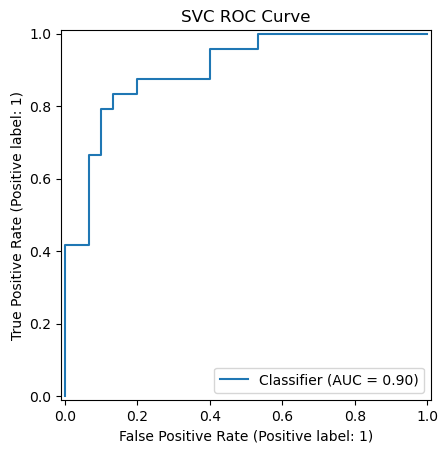

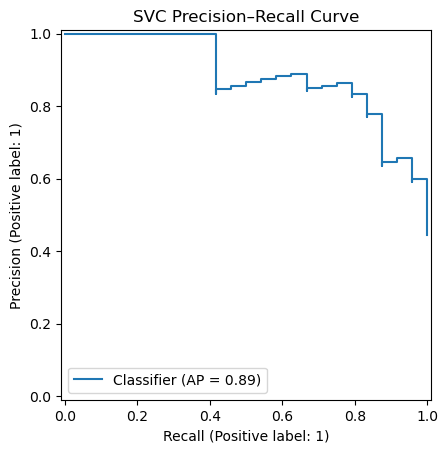

In [54]:
#ROC Curve + Precision-Recall Curve
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("SVC ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("SVC Precision–Recall Curve")
plt.show()


In [56]:
#Model Interpretation (Permutation Importance)
from sklearn.inspection import permutation_importance
import pandas as pd

# Feature names after preprocessing
feature_names = num_cols.copy()
cat_pipe = best_model.named_steps["preprocessor"].named_transformers_.get("cat")

if cat_pipe is not None:
    # Check if the pipeline has been fitted
    try:
        ohe = cat_pipe.named_steps["onehot"]
        # Only try to get feature names if the encoder has been fitted
        if hasattr(ohe, "get_feature_names_out"):
            feature_names += ohe.get_feature_names_out(cat_cols).tolist()
    except Exception as e:
        print(f"Warning: Could not get categorical feature names: {e}")
        # If we can't get transformed feature names, just use original column names
        feature_names += cat_cols

# Make sure the number of features matches what the model expects
# You might need to adjust this part based on your actual data
if len(feature_names) != X_test.shape[1]:
    print(f"Warning: Feature names count ({len(feature_names)}) doesn't match X_test shape ({X_test.shape[1]})")
    # Use generic feature names as fallback
    feature_names = [f"feature_{i}" for i in range(X_test.shape[1])]

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": feature_names[:len(perm.importances_mean)],  # Ensure lengths match
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

imp_df.head(15)


,feature,importance
12,Thallium,0.079012
11,Number of vessels fluro,0.053086
2,Chest pain type,0.027160
7,Max HR,0.025926
10,Slope of ST,0.014815
3,BP,0.013580
9,ST depression,0.008642
1,Sex,0.007407
0,Age,0.003704
8,Exercise angina,0.002469


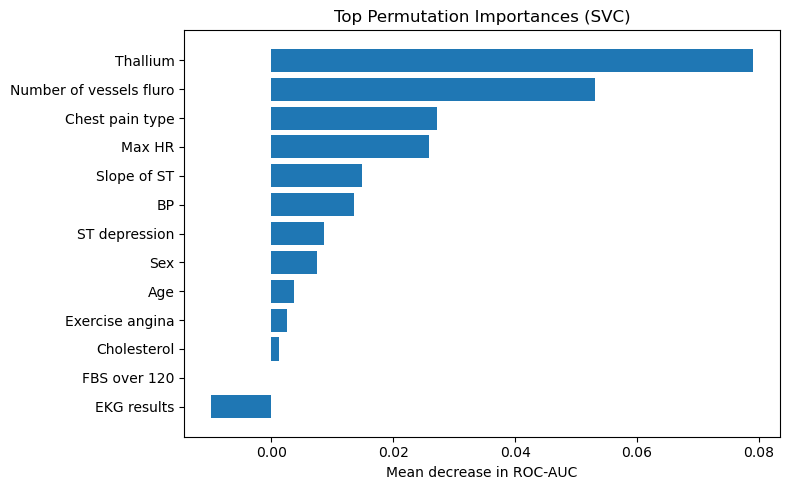

In [57]:
# Plot top features
top = imp_df.head(15).iloc[::-1]
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.title("Top Permutation Importances (SVC)")
plt.xlabel("Mean decrease in ROC-AUC")
plt.tight_layout()
plt.show()


In [ ]:
#Among all evaluated models, the Support Vector Classifier with an RBF kernel achieved the highest ROC-AUC, 
#indicating superior ability to distinguish between patients with and without heart disease. Given the medical context, 
#ROC-AUC and recall were prioritized over accuracy alone. Hyperparameter tuning further improved discrimination performance, 
#making SVC the final selected model.